In [1]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, utils
import matplotlib.pyplot as plt

In [2]:
# Install kaggle
!pip install -q kaggle

# Upload kaggle.json (you'll get a button)
from google.colab import files
files.upload()

# Setup kaggle
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download + unzip dataset
!kaggle datasets download -d puneet6060/intel-image-classification
!unzip -q intel-image-classification.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:01<00:00, 322MB/s]



In [3]:
def tf_he(images, labels):
    images = tf.cast(images, tf.uint8)

    def he(img):
        ycrcb = cv2.cvtColor(img, cv2.COLOR_RGB2YCrCb)
        ycrcb[:,:,0] = cv2.equalizeHist(ycrcb[:,:,0])
        return cv2.cvtColor(ycrcb, cv2.COLOR_YCrCb2RGB)

    images = tf.map_fn(
        lambda x: tf.numpy_function(he, [x], tf.uint8),
        images
    )

    images.set_shape([None, 128, 128, 3])

    return images, labels

In [4]:
def tf_clahe(images, labels):
    images = tf.cast(images, tf.uint8)

    def clahe(img):
        ycrcb = cv2.cvtColor(img, cv2.COLOR_RGB2YCrCb)
        ycrcb[:,:,0] = cv2.createCLAHE(2.0, (8,8)).apply(ycrcb[:,:,0])
        return cv2.cvtColor(ycrcb, cv2.COLOR_YCrCb2RGB)

    images = tf.map_fn(
        lambda x: tf.numpy_function(clahe, [x], tf.uint8),
        images
    )

    images.set_shape([None, 128, 128, 3])

    return images, labels

In [5]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/seg_train/seg_train",
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/seg_test/seg_test",
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    shuffle = False
)

Found 14034 files belonging to 6 classes.
Found 3000 files belonging to 6 classes.


In [6]:
train_raw = train_ds

train_he = train_ds.map(tf_he)

train_clahe = train_ds.map(tf_clahe)

val_raw = val_ds

val_he = val_ds.map(tf_he)

val_clahe = val_ds.map(tf_clahe)

In [7]:
class_names = train_ds.class_names
print(class_names)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


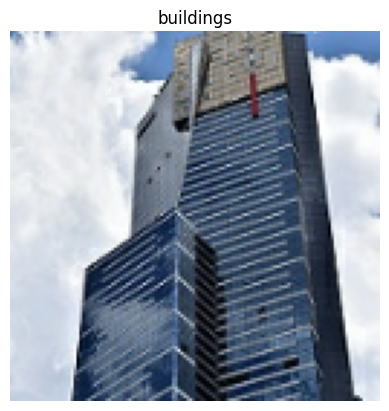

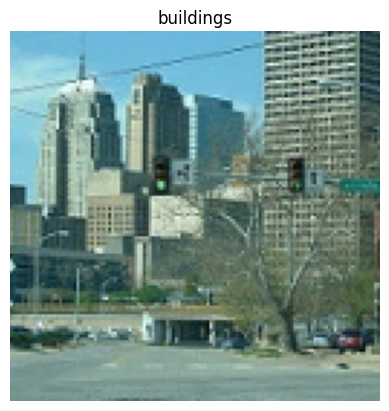

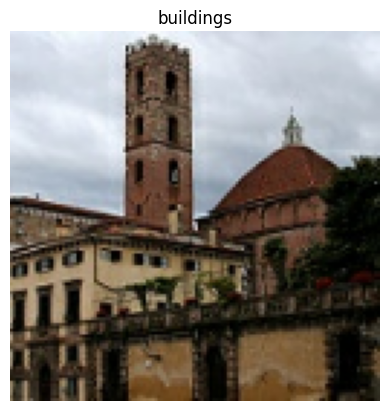

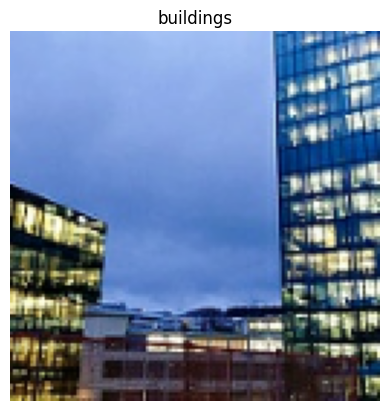

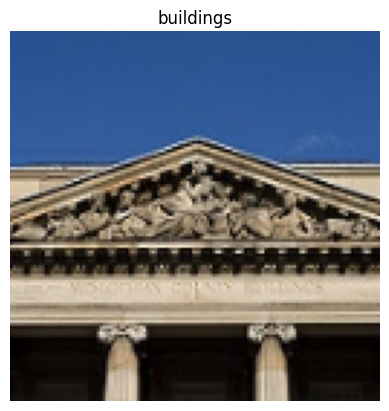

In [8]:
for images, labels in val_raw.take(1):
    for i in range(5):
       plt.imshow(images[i].numpy().astype("uint8"))
       plt.title(class_names[labels[i]])
       plt.axis("off")
       plt.show()

In [9]:
def residual_block(x, filters, downsample=False):

    shortcut = x
    stride = 2 if downsample else 1

    x = layers.Conv2D(filters, 3, strides=stride, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)

    # adjust shortcut if shape changes
    if downsample or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)

    return x

In [10]:
def build_resnet(input_shape=(128,128,3), num_classes=6):

    inputs = layers.Input(shape=input_shape)

    x = layers.Rescaling(1./255)(inputs)
    x = layers.Conv2D(32, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = residual_block(x, 32)
    x = residual_block(x, 64, downsample=True)
    x = residual_block(x, 64)
    x = residual_block(x, 128, downsample=True)
    x = residual_block(x, 128)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs, outputs)

In [11]:
model = build_resnet()

In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model with train clahe and validation clahe

In [13]:
history = model.fit(
    train_clahe,   # change to raw / he / clahe
    validation_data=val_clahe,
    epochs=12
)

Epoch 1/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 48s 61ms/step - accuracy: 0.6159 - loss: 0.9876 - val_accuracy: 0.5610 - val_loss: 1.1463
Epoch 2/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.7458 - loss: 0.6954 - val_accuracy: 0.7850 - val_loss: 0.6007
Epoch 3/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.7848 - loss: 0.5969 - val_accuracy: 0.7493 - val_loss: 0.6836
Epoch 4/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.8090 - loss: 0.5399 - val_accuracy: 0.8043 - val_loss: 0.5236
Epoch 5/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.8254 - loss: 0.4907 - val_accuracy: 0.8230 - val_loss: 0.4770
Epoch 6/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.8370 - loss: 0.4566 - val_accuracy: 0.7927 - val_loss: 0.5925
Epoch 7/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.8503 - loss: 0.4285 - val_accuracy: 0.8347 - val_loss: 0.4559
Epoch 8/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.8524 - loss: 0.4180 - 

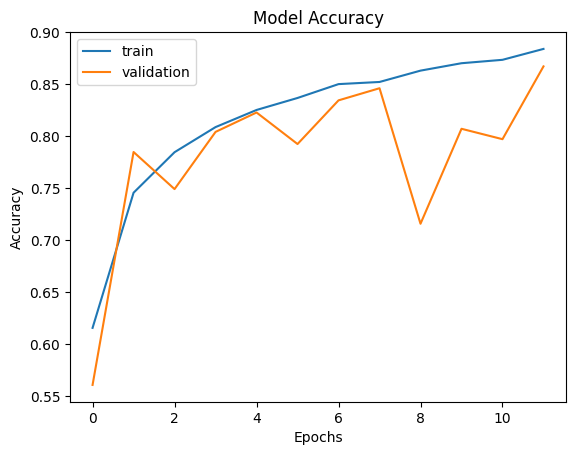

In [14]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['train', 'validation'])
plt.show()

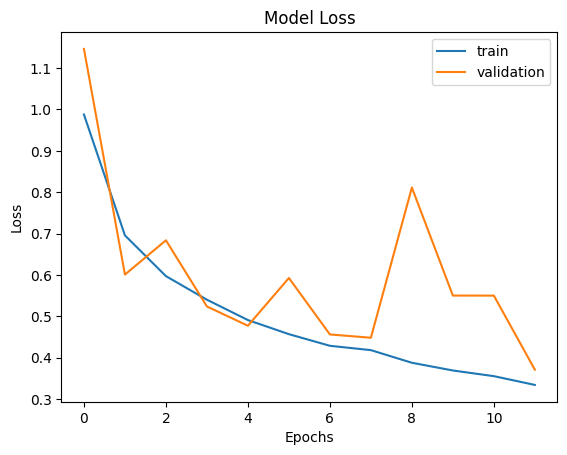

In [15]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['train', 'validation'])
plt.show()

In [16]:
y_true = []
y_pred = []

for x, y in val_clahe:
    preds = model.predict(x, verbose=0)
    y_pred.extend(preds.argmax(axis=1))
    y_true.extend(y.numpy())

In [17]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[349   1   3   2   3  79]
 [  1 453   2   2   1  15]
 [  4   0 488  35  20   6]
 [  2   3 100 390  28   2]
 [  9   2  26  14 454   5]
 [ 21   1   1   4   6 468]]


In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names = class_names))

              precision    recall  f1-score   support

   buildings       0.90      0.80      0.85       437
      forest       0.98      0.96      0.97       474
     glacier       0.79      0.88      0.83       553
    mountain       0.87      0.74      0.80       525
         sea       0.89      0.89      0.89       510
      street       0.81      0.93      0.87       501

    accuracy                           0.87      3000
   macro avg       0.87      0.87      0.87      3000
weighted avg       0.87      0.87      0.87      3000



# Train raw with validation raw

In [19]:
model = build_resnet()

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history1 = model.fit(
    train_raw,
    validation_data=val_raw,
    epochs=12
)

Epoch 1/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 32s 40ms/step - accuracy: 0.5926 - loss: 1.0506 - val_accuracy: 0.5917 - val_loss: 1.1775
Epoch 2/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.7255 - loss: 0.7386 - val_accuracy: 0.7500 - val_loss: 0.6851
Epoch 3/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.7686 - loss: 0.6294 - val_accuracy: 0.7357 - val_loss: 0.7091
Epoch 4/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.7963 - loss: 0.5608 - val_accuracy: 0.6847 - val_loss: 0.9227
Epoch 5/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.8178 - loss: 0.5111 - val_accuracy: 0.7213 - val_loss: 0.8076
Epoch 6/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.8333 - loss: 0.4747 - val_accuracy: 0.7907 - val_loss: 0.5509
Epoch 7/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.8400 - loss: 0.4596 - val_accuracy: 0.8237 - val_loss: 0.4723
Epoch 8/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.8515 - loss: 0.4239 - val_acc

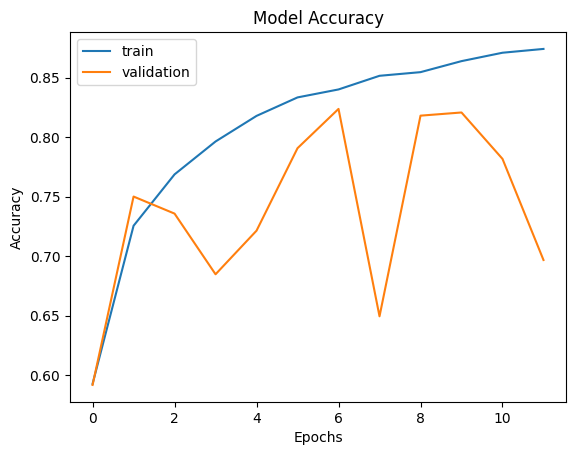

In [20]:
plt.plot(history1.history['accuracy'])
plt.plot(history1.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['train', 'validation'])
plt.show()

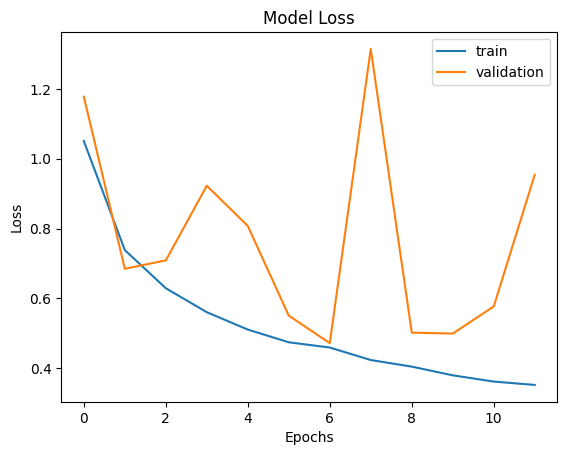

In [21]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['train', 'validation'])
plt.show()

In [22]:
y_true = []
y_pred = []

for x, y in val_raw:
    preds = model.predict(x, verbose=0)
    y_pred.extend(preds.argmax(axis=1))
    y_true.extend(y.numpy())

In [23]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[348   0   0   0   0  89]
 [ 14 233   0   2   1 224]
 [  9   1 322  35  27 159]
 [ 15   3  35 317  57  98]
 [  8   1   6   1 420  74]
 [ 46   0   0   0   5 450]]


In [24]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names = class_names))

              precision    recall  f1-score   support

   buildings       0.79      0.80      0.79       437
      forest       0.98      0.49      0.65       474
     glacier       0.89      0.58      0.70       553
    mountain       0.89      0.60      0.72       525
         sea       0.82      0.82      0.82       510
      street       0.41      0.90      0.56       501

    accuracy                           0.70      3000
   macro avg       0.80      0.70      0.71      3000
weighted avg       0.80      0.70      0.71      3000



# Train he with validation he

In [25]:
model = build_resnet()

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(
    train_he,
    validation_data=val_he,
    epochs=12
)

Epoch 1/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.6074 - loss: 1.0211 - val_accuracy: 0.5293 - val_loss: 1.1114
Epoch 2/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.7422 - loss: 0.7013 - val_accuracy: 0.6530 - val_loss: 0.9280
Epoch 3/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.7756 - loss: 0.6122 - val_accuracy: 0.7347 - val_loss: 0.7272
Epoch 4/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.8026 - loss: 0.5470 - val_accuracy: 0.7227 - val_loss: 0.7370
Epoch 5/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.8165 - loss: 0.5114 - val_accuracy: 0.5937 - val_loss: 1.1737
Epoch 6/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.8301 - loss: 0.4814 - val_accuracy: 0.7110 - val_loss: 0.7324
Epoch 7/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.8405 - loss: 0.4512 - val_accuracy: 0.7600 - val_loss: 0.6253
Epoch 8/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.8484 - loss: 0.4302 - val_acc

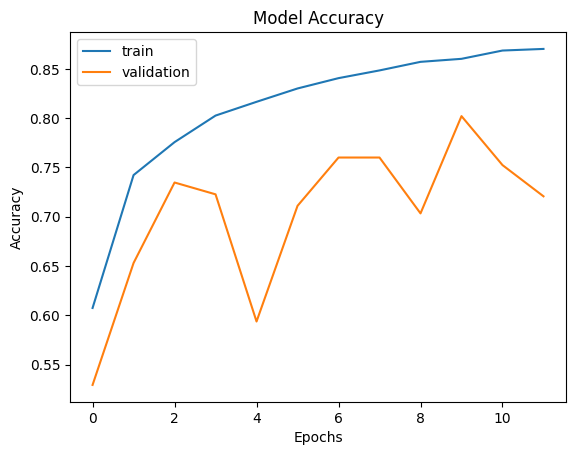

In [26]:
plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['train', 'validation'])
plt.show()

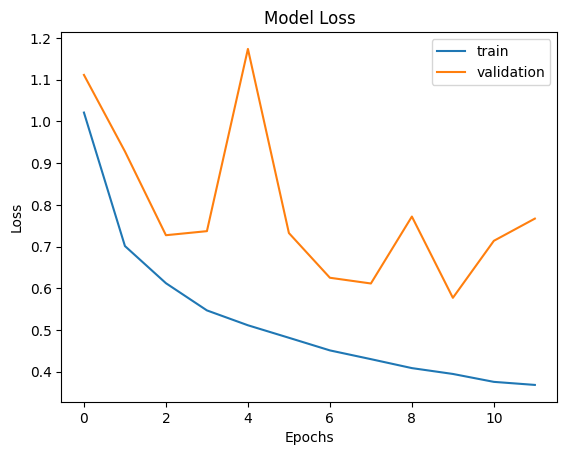

In [27]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['train', 'validation'])
plt.show()

In [28]:
y_true = []
y_pred = []

for x, y in val_he:
    preds = model.predict(x, verbose=0)
    y_pred.extend(preds.argmax(axis=1))
    y_true.extend(y.numpy())

In [29]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[406   1   0   1   3  26]
 [ 22 446   0   1   1   4]
 [162  24 103 123  60  81]
 [ 48   7   5 395  53  17]
 [ 61   6   0   7 420  16]
 [100   1   0   2   6 392]]


In [30]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names = class_names))

              precision    recall  f1-score   support

   buildings       0.51      0.93      0.66       437
      forest       0.92      0.94      0.93       474
     glacier       0.95      0.19      0.31       553
    mountain       0.75      0.75      0.75       525
         sea       0.77      0.82      0.80       510
      street       0.73      0.78      0.76       501

    accuracy                           0.72      3000
   macro avg       0.77      0.74      0.70      3000
weighted avg       0.78      0.72      0.69      3000



# Train clahe with validation raw

In [31]:
model = build_resnet()

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history3 = model.fit(
    train_clahe,
    validation_data=val_raw,
    epochs=12
)

Epoch 1/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 33s 41ms/step - accuracy: 0.6213 - loss: 0.9674 - val_accuracy: 0.3443 - val_loss: 1.8110
Epoch 2/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.7542 - loss: 0.6713 - val_accuracy: 0.6553 - val_loss: 0.8605
Epoch 3/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.7894 - loss: 0.5801 - val_accuracy: 0.5903 - val_loss: 0.9357
Epoch 4/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.8127 - loss: 0.5241 - val_accuracy: 0.7277 - val_loss: 0.7546
Epoch 5/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.8248 - loss: 0.4871 - val_accuracy: 0.7373 - val_loss: 0.6832
Epoch 6/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.8423 - loss: 0.4493 - val_accuracy: 0.6813 - val_loss: 0.9017
Epoch 7/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.8525 - loss: 0.4205 - val_accuracy: 0.6943 - val_loss: 0.7519
Epoch 8/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.8583 - loss: 0.4013 - val_acc

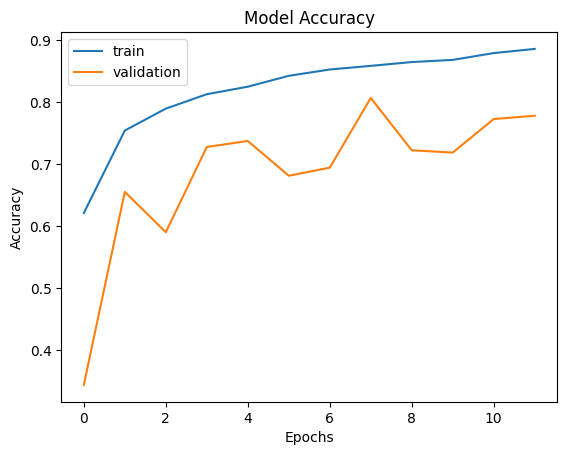

In [32]:
plt.plot(history3.history['accuracy'])
plt.plot(history3.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['train', 'validation'])
plt.show()

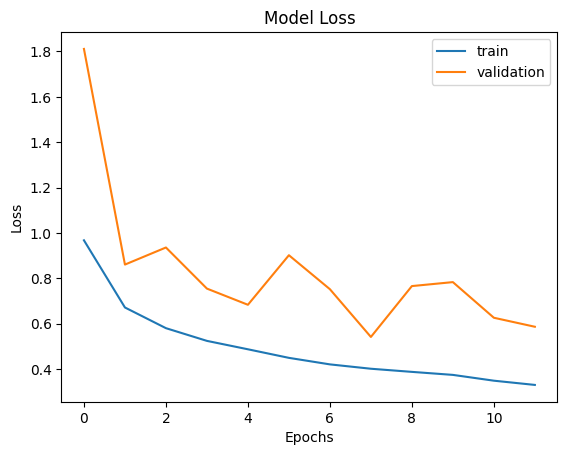

In [33]:
plt.plot(history3.history['loss'])
plt.plot(history3.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['train', 'validation'])
plt.show()

In [34]:
y_true = []
y_pred = []

for x, y in val_raw:
    preds = model.predict(x, verbose=0)
    y_pred.extend(preds.argmax(axis=1))
    y_true.extend(y.numpy())

In [35]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[271   1   1  11  14 139]
 [  1 434   2   1   4  32]
 [  1   2 259 188  70  33]
 [  0   3  18 454  31  19]
 [  4   5   6  41 443  11]
 [ 14   3   0   5   6 473]]


In [36]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names = class_names))

              precision    recall  f1-score   support

   buildings       0.93      0.62      0.74       437
      forest       0.97      0.92      0.94       474
     glacier       0.91      0.47      0.62       553
    mountain       0.65      0.86      0.74       525
         sea       0.78      0.87      0.82       510
      street       0.67      0.94      0.78       501

    accuracy                           0.78      3000
   macro avg       0.82      0.78      0.77      3000
weighted avg       0.81      0.78      0.77      3000



# Train he with validation raw

In [37]:
model = build_resnet()

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history4 = model.fit(
    train_he,
    validation_data=val_raw,
    epochs=12
)

Epoch 1/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 32s 40ms/step - accuracy: 0.5765 - loss: 1.1137 - val_accuracy: 0.3290 - val_loss: 2.1171
Epoch 2/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.7284 - loss: 0.7342 - val_accuracy: 0.5690 - val_loss: 1.2202
Epoch 3/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.7730 - loss: 0.6250 - val_accuracy: 0.7347 - val_loss: 0.7389
Epoch 4/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.7966 - loss: 0.5635 - val_accuracy: 0.7553 - val_loss: 0.6943
Epoch 5/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.8150 - loss: 0.5143 - val_accuracy: 0.7380 - val_loss: 0.7039
Epoch 6/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.8296 - loss: 0.4799 - val_accuracy: 0.7127 - val_loss: 0.7866
Epoch 7/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.8378 - loss: 0.4572 - val_accuracy: 0.7723 - val_loss: 0.6446
Epoch 8/12
439/439 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.8437 - loss: 0.4406 - val_acc

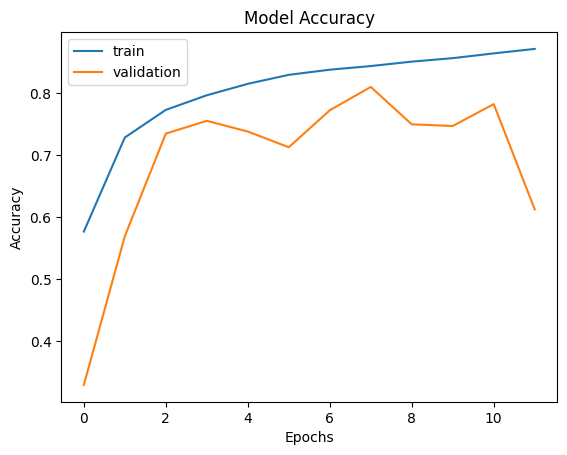

In [38]:
plt.plot(history4.history['accuracy'])
plt.plot(history4.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['train', 'validation'])
plt.show()

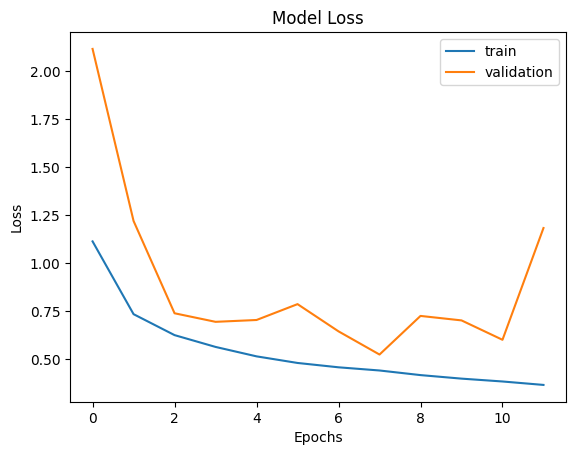

In [39]:
plt.plot(history4.history['loss'])
plt.plot(history4.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['train', 'validation'])
plt.show()

In [40]:
y_true = []
y_pred = []

for x, y in val_raw:
    preds = model.predict(x, verbose=0)
    y_pred.extend(preds.argmax(axis=1))
    y_true.extend(y.numpy())

In [41]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[128  20   3   1  34 251]
 [  0 412   2   0  15  45]
 [  1   6 332   8  30 176]
 [  0   9  72 131 156 157]
 [  3   3  14   1 394  95]
 [  2  28   0   0  31 440]]


In [42]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names = class_names))

              precision    recall  f1-score   support

   buildings       0.96      0.29      0.45       437
      forest       0.86      0.87      0.87       474
     glacier       0.78      0.60      0.68       553
    mountain       0.93      0.25      0.39       525
         sea       0.60      0.77      0.67       510
      street       0.38      0.88      0.53       501

    accuracy                           0.61      3000
   macro avg       0.75      0.61      0.60      3000
weighted avg       0.75      0.61      0.60      3000

